In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.manifold import TSNE

import wandb

/opt/homebrew/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

full_dataset = torch.utils.data.ConcatDataset([full_train_dataset, test_dataset_full])

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 56000
Val:   7000
Test:  7000


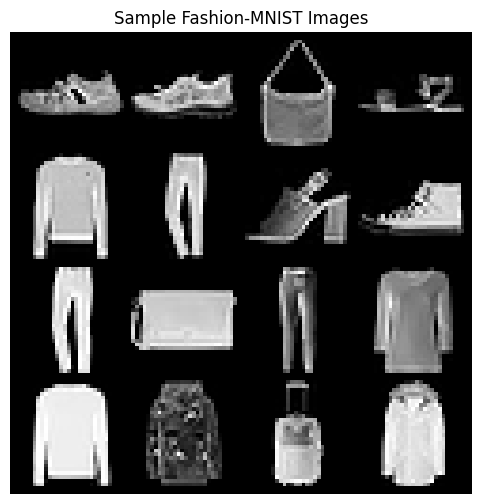

In [4]:
def show_batch(loader):
    images, labels = next(iter(loader))
    grid = make_grid(images[:16], nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Sample Fashion-MNIST Images")
    plt.show()

show_batch(train_loader)

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x_recon = self.decoder(z)
        return x_recon.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [7]:
def ae_loss_function(recon_x, x, loss_type="bce"):
    if loss_type == "bce":
        return F.binary_cross_entropy(recon_x, x, reduction="mean")
    elif loss_type == "mse":
        return F.mse_loss(recon_x, x, reduction="mean")
    else:
        raise ValueError("loss_type must be 'bce' or 'mse'")


def vae_loss_function(recon_x, x, mu, logvar, loss_type="bce", beta=1.0):
    if loss_type == "bce":
        recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    elif loss_type == "mse":
        recon_loss = F.mse_loss(recon_x, x, reduction="mean")
    else:
        raise ValueError("loss_type must be 'bce' or 'mse'")
    
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [8]:
def get_optimizer(model, optimizer_name="adam", lr=1e-3):
    optimizer_name = optimizer_name.lower()
    
    if optimizer_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name must be 'sgd', 'rmsprop', or 'adam'")

In [9]:
def train_autoencoder(model, train_loader, val_loader, optimizer, loss_type="bce", epochs=10):
    history = {
        "train_loss": [],
        "val_loss": []
    }
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for images, _ in train_loader:
            images = images.to(device)
            
            optimizer.zero_grad()
            recon = model(images)
            loss = ae_loss_function(recon, images, loss_type=loss_type)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                recon = model(images)
                loss = ae_loss_function(recon, images, loss_type=loss_type)
                val_loss += loss.item() * images.size(0)
        
        val_loss /= len(val_loader.dataset)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    return history

In [10]:
def train_vae(model, train_loader, val_loader, optimizer, loss_type="bce", epochs=10, beta=1.0):
    history = {
        "train_total_loss": [],
        "train_recon_loss": [],
        "train_kl_loss": [],
        "val_total_loss": [],
        "val_recon_loss": [],
        "val_kl_loss": []
    }
    
    for epoch in range(epochs):
        model.train()
        train_total = 0.0
        train_recon = 0.0
        train_kl = 0.0
        
        for images, _ in train_loader:
            images = images.to(device)
            
            optimizer.zero_grad()
            recon, mu, logvar = model(images)
            loss, recon_loss, kl_loss = vae_loss_function(
                recon, images, mu, logvar, loss_type=loss_type, beta=beta
            )
            loss.backward()
            optimizer.step()
            
            train_total += loss.item() * images.size(0)
            train_recon += recon_loss.item() * images.size(0)
            train_kl += kl_loss.item() * images.size(0)
        
        train_total /= len(train_loader.dataset)
        train_recon /= len(train_loader.dataset)
        train_kl /= len(train_loader.dataset)
        
        model.eval()
        val_total = 0.0
        val_recon = 0.0
        val_kl = 0.0
        
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                recon, mu, logvar = model(images)
                loss, recon_loss, kl_loss = vae_loss_function(
                    recon, images, mu, logvar, loss_type=loss_type, beta=beta
                )
                
                val_total += loss.item() * images.size(0)
                val_recon += recon_loss.item() * images.size(0)
                val_kl += kl_loss.item() * images.size(0)
        
        val_total /= len(val_loader.dataset)
        val_recon /= len(val_loader.dataset)
        val_kl /= len(val_loader.dataset)
        
        history["train_total_loss"].append(train_total)
        history["train_recon_loss"].append(train_recon)
        history["train_kl_loss"].append(train_kl)
        history["val_total_loss"].append(val_total)
        history["val_recon_loss"].append(val_recon)
        history["val_kl_loss"].append(val_kl)
        
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Total: {train_total:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f} | "
            f"Val Total: {val_total:.4f}, Recon: {val_recon:.4f}, KL: {val_kl:.4f}"
        )
    
    return history

In [11]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(8, 5))
    for key, values in history.items():
        plt.plot(values, label=key)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
def show_reconstructions(model, loader, model_type="ae", n=8):
    model.eval()
    images, _ = next(iter(loader))
    images = images[:n].to(device)
    
    with torch.no_grad():
        if model_type == "ae":
            recon = model(images)
        else:
            recon, _, _ = model(images)
    
    images = images.cpu()
    recon = recon.cpu()
    
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
    
    axes[0, 0].set_title("Original")
    axes[1, 0].set_title("Recon")
    plt.tight_layout()
    plt.show()

In [13]:
def generate_from_vae(model, num_samples=16):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, model.fc_mu.out_features).to(device)
        samples = model.decode(z).cpu()
    
    grid = make_grid(samples, nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Generated Samples from VAE")
    plt.show()

In [14]:
def extract_latent_vectors(model, loader, model_type="ae"):
    model.eval()
    latent_vectors = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            if model_type == "ae":
                z = model.encoder(images)
            else:
                mu, logvar = model.encode(images)
                z = mu
            
            latent_vectors.append(z.cpu())
            labels_list.append(labels)
    
    latent_vectors = torch.cat(latent_vectors, dim=0).numpy()
    labels_list = torch.cat(labels_list, dim=0).numpy()
    
    return latent_vectors, labels_list

In [15]:
def plot_latent_space(latent_vectors, labels, title="Latent Space"):
    if latent_vectors.shape[1] == 2:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            latent_vectors[:, 0], latent_vectors[:, 1],
            c=labels, cmap="tab10", s=8
        )
        plt.colorbar(scatter)
        plt.title(title)
        plt.xlabel("z1")
        plt.ylabel("z2")
        plt.grid(True)
        plt.show()
    else:
        tsne = TSNE(n_components=2, random_state=42)
        reduced = tsne.fit_transform(latent_vectors)
        
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            reduced[:, 0], reduced[:, 1],
            c=labels, cmap="tab10", s=8
        )
        plt.colorbar(scatter)
        plt.title(title + " (t-SNE)")
        plt.grid(True)
        plt.show()

In [16]:
def latent_interpolation(model, img1, img2, model_type="ae", steps=10):
    model.eval()
    
    img1 = img1.unsqueeze(0).to(device)
    img2 = img2.unsqueeze(0).to(device)
    
    with torch.no_grad():
        if model_type == "ae":
            z1 = model.encoder(img1)
            z2 = model.encoder(img2)
            decoder = model.decoder
        else:
            mu1, _ = model.encode(img1)
            mu2, _ = model.encode(img2)
            z1, z2 = mu1, mu2
            decoder = model.decode
        
        interpolated_images = []
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            if model_type == "ae":
                recon = decoder(z).view(-1, 1, 28, 28)
            else:
                recon = decoder(z)
            interpolated_images.append(recon.cpu().squeeze(0))
    
    fig, axes = plt.subplots(1, steps, figsize=(2*steps, 2))
    for i, img in enumerate(interpolated_images):
        axes[i].imshow(img.squeeze(), cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"{i}")
    plt.tight_layout()
    plt.show()

In [17]:
def evaluate_autoencoder(model, loader, loss_type="bce"):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            recon = model(images)
            loss = ae_loss_function(recon, images, loss_type=loss_type)
            total_loss += loss.item() * images.size(0)
    
    return total_loss / len(loader.dataset)


def evaluate_vae(model, loader, loss_type="bce", beta=1.0):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            recon, mu, logvar = model(images)
            loss, recon_loss, kl_loss = vae_loss_function(
                recon, images, mu, logvar, loss_type=loss_type, beta=beta
            )
            total_loss += loss.item() * images.size(0)
            total_recon += recon_loss.item() * images.size(0)
            total_kl += kl_loss.item() * images.size(0)
    
    total_loss /= len(loader.dataset)
    total_recon /= len(loader.dataset)
    total_kl /= len(loader.dataset)
    
    return total_loss, total_recon, total_kl

Epoch [1/10] | Train Loss: 0.3395 | Val Loss: 0.3033
Epoch [2/10] | Train Loss: 0.2961 | Val Loss: 0.2936
Epoch [3/10] | Train Loss: 0.2894 | Val Loss: 0.2884
Epoch [4/10] | Train Loss: 0.2849 | Val Loss: 0.2842
Epoch [5/10] | Train Loss: 0.2816 | Val Loss: 0.2814
Epoch [6/10] | Train Loss: 0.2791 | Val Loss: 0.2799
Epoch [7/10] | Train Loss: 0.2773 | Val Loss: 0.2781
Epoch [8/10] | Train Loss: 0.2759 | Val Loss: 0.2767
Epoch [9/10] | Train Loss: 0.2749 | Val Loss: 0.2762
Epoch [10/10] | Train Loss: 0.2741 | Val Loss: 0.2754


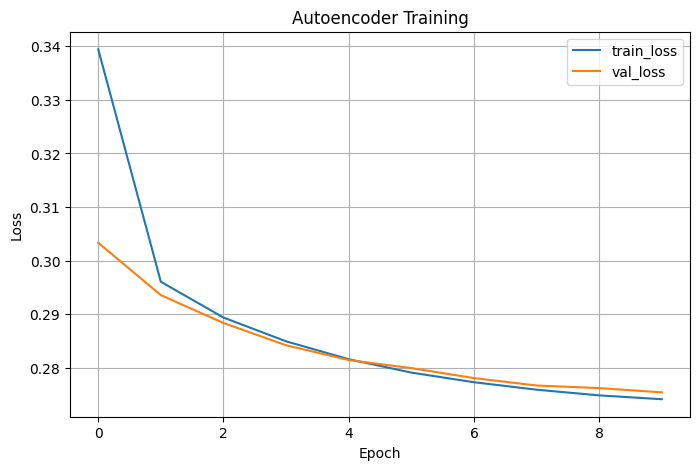

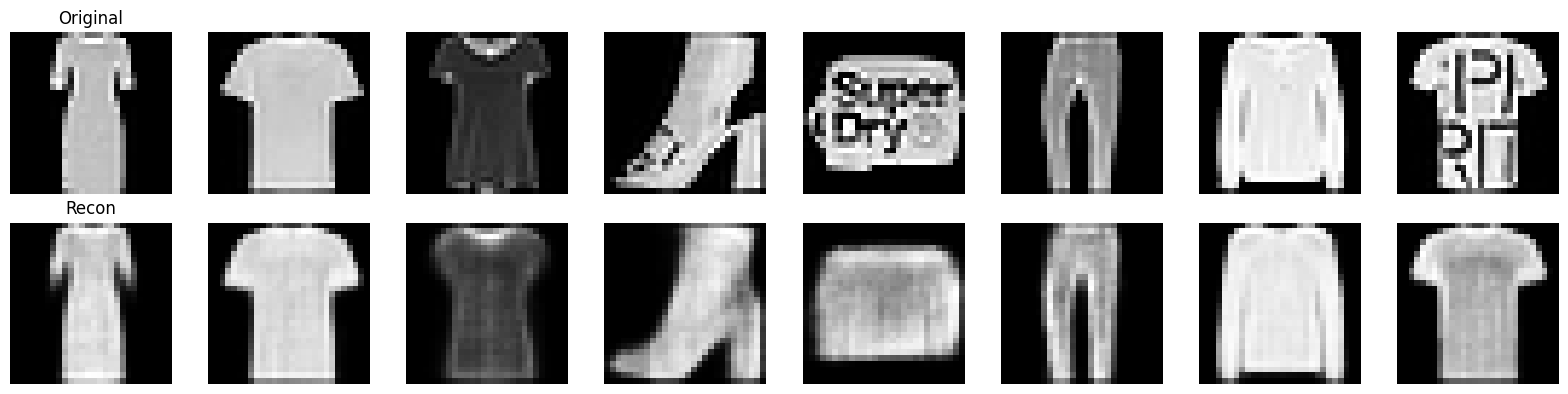

Autoencoder Test Loss: 0.27570303641046795


In [18]:
latent_dim = 16
loss_type = "bce"
optimizer_name = "adam"
epochs = 10

ae_model = Autoencoder(latent_dim=latent_dim).to(device)
ae_optimizer = get_optimizer(ae_model, optimizer_name=optimizer_name, lr=1e-3)

ae_history = train_autoencoder(
    ae_model,
    train_loader,
    val_loader,
    ae_optimizer,
    loss_type=loss_type,
    epochs=epochs
)

plot_history(ae_history, title="Autoencoder Training")
show_reconstructions(ae_model, test_loader, model_type="ae")

ae_test_loss = evaluate_autoencoder(ae_model, test_loader, loss_type=loss_type)
print("Autoencoder Test Loss:", ae_test_loss)

Epoch [1/10] | Train Total: 0.4927, Recon: 0.4845, KL: 0.0083 | Val Total: 0.4859, Recon: 0.4695, KL: 0.0164
Epoch [2/10] | Train Total: 0.4817, Recon: 0.4489, KL: 0.0328 | Val Total: 0.4783, Recon: 0.4323, KL: 0.0460
Epoch [3/10] | Train Total: 0.4776, Recon: 0.4315, KL: 0.0461 | Val Total: 0.4773, Recon: 0.4321, KL: 0.0451
Epoch [4/10] | Train Total: 0.4768, Recon: 0.4293, KL: 0.0476 | Val Total: 0.4768, Recon: 0.4281, KL: 0.0487
Epoch [5/10] | Train Total: 0.4765, Recon: 0.4280, KL: 0.0485 | Val Total: 0.4771, Recon: 0.4270, KL: 0.0501
Epoch [6/10] | Train Total: 0.4762, Recon: 0.4270, KL: 0.0493 | Val Total: 0.4772, Recon: 0.4289, KL: 0.0482
Epoch [7/10] | Train Total: 0.4758, Recon: 0.4268, KL: 0.0490 | Val Total: 0.4764, Recon: 0.4301, KL: 0.0462
Epoch [8/10] | Train Total: 0.4758, Recon: 0.4268, KL: 0.0490 | Val Total: 0.4766, Recon: 0.4267, KL: 0.0499
Epoch [9/10] | Train Total: 0.4766, Recon: 0.4267, KL: 0.0499 | Val Total: 0.4758, Recon: 0.4296, KL: 0.0462
Epoch [10/10] | Tra

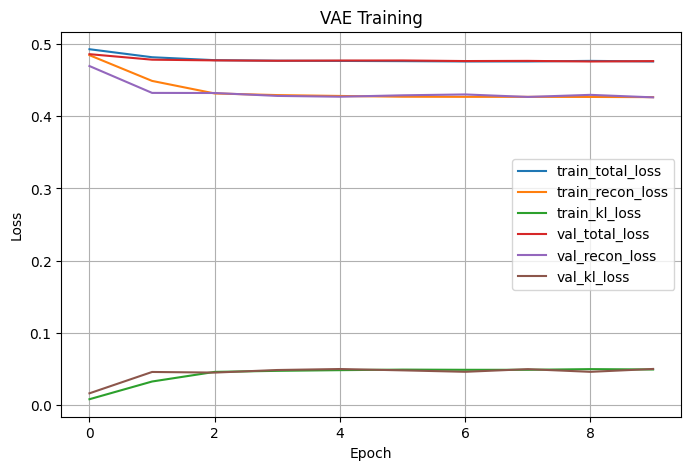

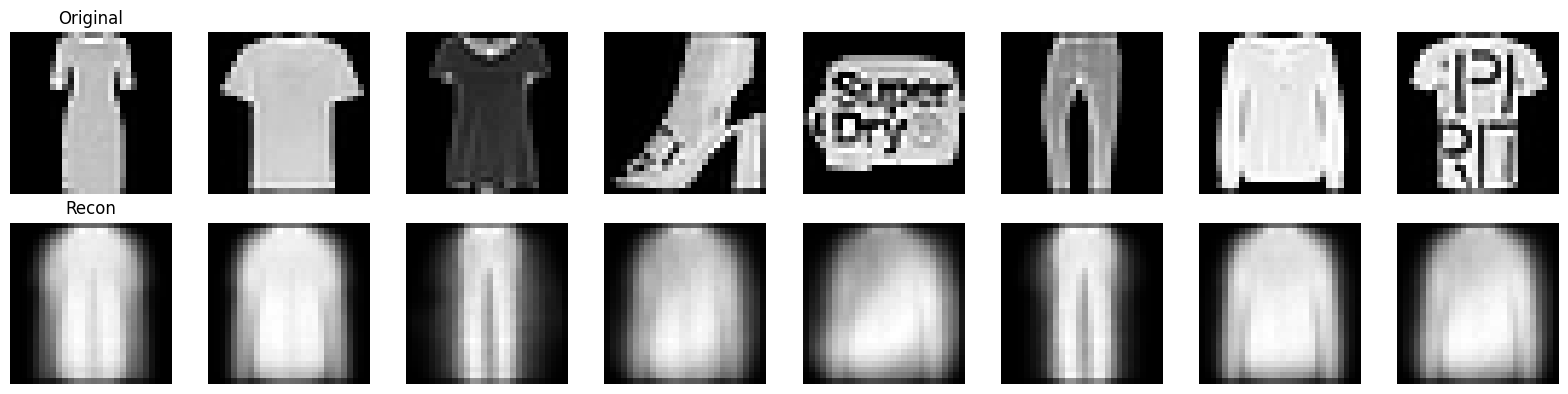

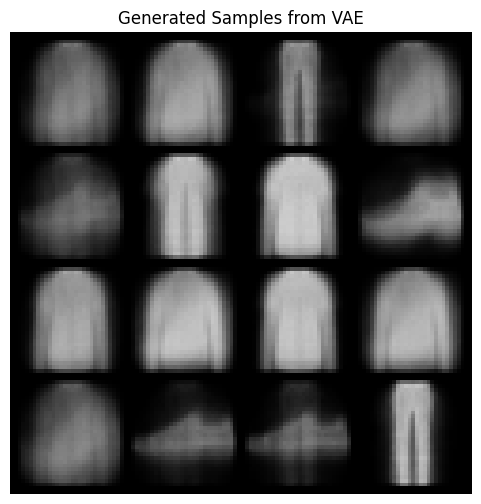

VAE Test Total Loss: 0.47694153683526175
VAE Test Recon Loss: 0.42634117879186356
VAE Test KL Loss: 0.05060035867776189


In [19]:
latent_dim = 16
loss_type = "bce"
optimizer_name = "adam"
epochs = 10

vae_model = VAE(latent_dim=latent_dim).to(device)
vae_optimizer = get_optimizer(vae_model, optimizer_name=optimizer_name, lr=1e-3)

vae_history = train_vae(
    vae_model,
    train_loader,
    val_loader,
    vae_optimizer,
    loss_type=loss_type,
    epochs=epochs,
    beta=1.0
)

plot_history(vae_history, title="VAE Training")
show_reconstructions(vae_model, test_loader, model_type="vae")
generate_from_vae(vae_model)

vae_test_total, vae_test_recon, vae_test_kl = evaluate_vae(
    vae_model,
    test_loader,
    loss_type=loss_type,
    beta=1.0
)

print("VAE Test Total Loss:", vae_test_total)
print("VAE Test Recon Loss:", vae_test_recon)
print("VAE Test KL Loss:", vae_test_kl)

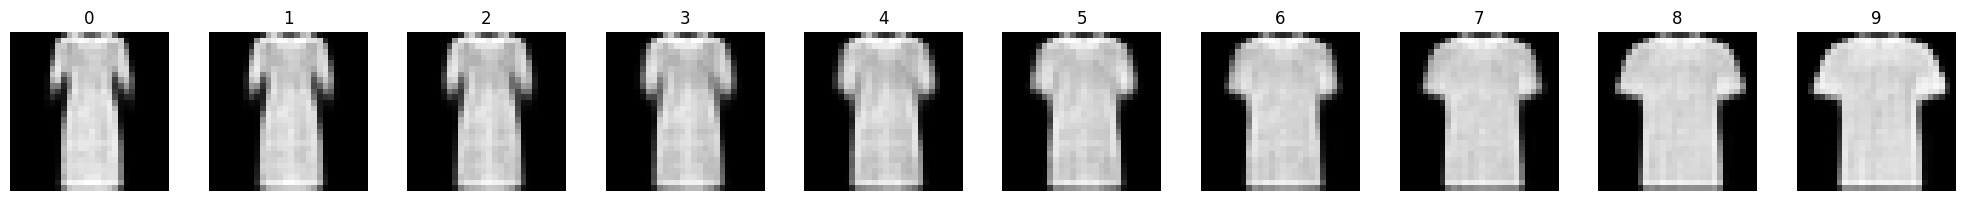

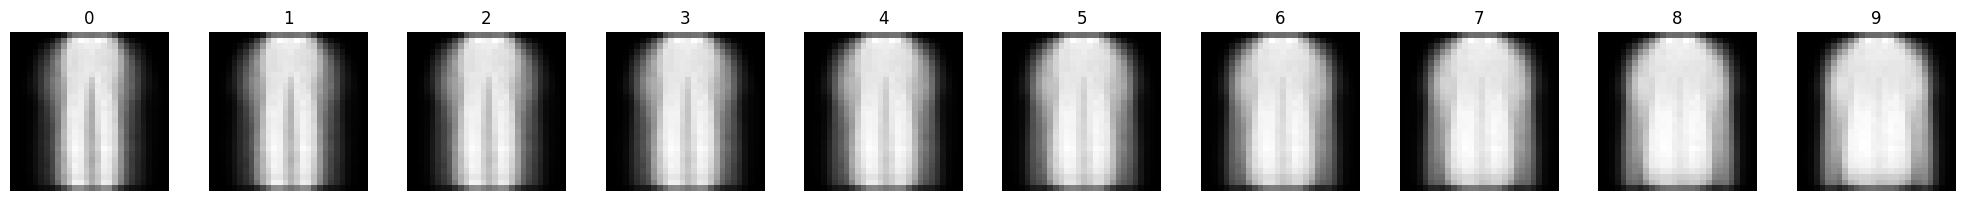

In [20]:
sample_images, sample_labels = next(iter(test_loader))
img1 = sample_images[0]
img2 = sample_images[1]

latent_interpolation(ae_model, img1, img2, model_type="ae", steps=10)
latent_interpolation(vae_model, img1, img2, model_type="vae", steps=10)

In [21]:
latent_dims = [2, 8, 16, 32]
loss_types = ["mse", "bce"]
optimizers_list = ["sgd", "rmsprop", "adam"]

results = []

for latent_dim in latent_dims:
    for loss_type in loss_types:
        for opt_name in optimizers_list:
            print(f"\n=== AE | latent={latent_dim} | loss={loss_type} | opt={opt_name} ===")
            ae_model = Autoencoder(latent_dim=latent_dim).to(device)
            ae_optimizer = get_optimizer(ae_model, optimizer_name=opt_name, lr=1e-3)
            
            train_autoencoder(
                ae_model,
                train_loader,
                val_loader,
                ae_optimizer,
                loss_type=loss_type,
                epochs=5
            )
            
            ae_test_loss = evaluate_autoencoder(ae_model, test_loader, loss_type=loss_type)
            results.append({
                "model": "AE",
                "latent_dim": latent_dim,
                "loss_type": loss_type,
                "optimizer": opt_name,
                "test_loss": ae_test_loss
            })

            print(f"\n=== VAE | latent={latent_dim} | loss={loss_type} | opt={opt_name} ===")
            vae_model = VAE(latent_dim=latent_dim).to(device)
            vae_optimizer = get_optimizer(vae_model, optimizer_name=opt_name, lr=1e-3)
            
            train_vae(
                vae_model,
                train_loader,
                val_loader,
                vae_optimizer,
                loss_type=loss_type,
                epochs=5,
                beta=1.0
            )
            
            vae_test_total, vae_test_recon, vae_test_kl = evaluate_vae(
                vae_model, test_loader, loss_type=loss_type, beta=1.0
            )
            
            results.append({
                "model": "VAE",
                "latent_dim": latent_dim,
                "loss_type": loss_type,
                "optimizer": opt_name,
                "test_loss": vae_test_total,
                "recon_loss": vae_test_recon,
                "kl_loss": vae_test_kl
            })


=== AE | latent=2 | loss=mse | opt=sgd ===
Epoch [1/5] | Train Loss: 0.1704 | Val Loss: 0.1695
Epoch [2/5] | Train Loss: 0.1689 | Val Loss: 0.1680
Epoch [3/5] | Train Loss: 0.1674 | Val Loss: 0.1664
Epoch [4/5] | Train Loss: 0.1658 | Val Loss: 0.1648
Epoch [5/5] | Train Loss: 0.1641 | Val Loss: 0.1630

=== VAE | latent=2 | loss=mse | opt=sgd ===
Epoch [1/5] | Train Total: 0.1709, Recon: 0.1705, KL: 0.0004 | Val Total: 0.1694, Recon: 0.1691, KL: 0.0003
Epoch [2/5] | Train Total: 0.1684, Recon: 0.1682, KL: 0.0002 | Val Total: 0.1671, Recon: 0.1669, KL: 0.0002
Epoch [3/5] | Train Total: 0.1661, Recon: 0.1659, KL: 0.0002 | Val Total: 0.1646, Recon: 0.1645, KL: 0.0002
Epoch [4/5] | Train Total: 0.1636, Recon: 0.1634, KL: 0.0002 | Val Total: 0.1621, Recon: 0.1619, KL: 0.0002
Epoch [5/5] | Train Total: 0.1609, Recon: 0.1607, KL: 0.0001 | Val Total: 0.1592, Recon: 0.1591, KL: 0.0001

=== AE | latent=2 | loss=mse | opt=rmsprop ===
Epoch [1/5] | Train Loss: 0.0400 | Val Loss: 0.0339
Epoch [2/5]

In [22]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("ae_vae_results.csv", index=False)

   model  latent_dim loss_type optimizer  test_loss  recon_loss       kl_loss
0     AE           2       mse       sgd   0.162923         NaN           NaN
1    VAE           2       mse       sgd   0.159113    0.158966  1.471445e-04
2     AE           2       mse   rmsprop   0.028750         NaN           NaN
3    VAE           2       mse   rmsprop   0.087534    0.087505  2.918851e-05
4     AE           2       mse      adam   0.027965         NaN           NaN
5    VAE           2       mse      adam   0.087513    0.087512  4.729245e-07
6     AE           2       bce       sgd   0.653459         NaN           NaN
7    VAE           2       bce       sgd   0.629495    0.629263  2.328110e-04
8     AE           2       bce   rmsprop   0.329719         NaN           NaN
9    VAE           2       bce   rmsprop   0.492524    0.492361  1.629169e-04
10    AE           2       bce      adam   0.323032         NaN           NaN
11   VAE           2       bce      adam   0.492447    0.492446 

In [23]:
torch.save(ae_model.state_dict(), "autoencoder_latent16.pth")
torch.save(vae_model.state_dict(), "vae_latent16.pth")

In [ ]:
def train_autoencoder_wandb(model, train_loader, val_loader, optimizer, config):
    wandb.init(entity="triptibhardwaj_25afi04", project="fashion-mnist-ae-vae", config=config)
    
    loss_type = config["loss_type"]
    epochs = config["epochs"]
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for images, _ in train_loader:
            images = images.to(device)
            
            optimizer.zero_grad()
            recon = model(images)
            loss = ae_loss_function(recon, images, loss_type=loss_type)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                recon = model(images)
                loss = ae_loss_function(recon, images, loss_type=loss_type)
                val_loss += loss.item() * images.size(0)
        
        val_loss /= len(val_loader.dataset)
        
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": optimizer.param_groups[0]['lr']
        })

        if epoch % 2 == 0:
            wandb.log({
                "reconstructions": wandb.Image(recon[0].cpu().numpy())
            })
        
        print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")
    
    wandb.finish()

In [25]:
latent_dims = [2, 8, 16, 32]
loss_types = ["bce", "mse"]
optimizers_list = ["sgd", "rmsprop", "adam"]

for latent_dim in latent_dims:
    for loss_type in loss_types:
        for opt_name in optimizers_list:
            model = Autoencoder(latent_dim=latent_dim).to(device)
            optimizer = get_optimizer(model, optimizer_name=opt_name, lr=1e-3)

            config = {
                "model": "Autoencoder",
                "latent_dim": latent_dim,
                "loss_type": loss_type,
                "optimizer": opt_name,
                "epochs": 5,
                "lr": 1e-3
            }

            train_autoencoder_wandb(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                config=config
            )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/mckyzcky/.netrc.
wandb: Currently logged in as: anmolkumar_25afi01 (anmolkumar_dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1: train=0.6916, val=0.6886
Epoch 2: train=0.6855, val=0.6823
Epoch 3: train=0.6788, val=0.6748
Epoch 4: train=0.6703, val=0.6651
Epoch 5: train=0.6591, val=0.6524


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_loss,█▇▅▃▁
val_loss,█▇▅▃▁
epoch,5
lr,0.001
train_loss,0.65911
val_loss,0.65238


Epoch 1: train=0.3668, val=0.3384
Epoch 2: train=0.3359, val=0.3383
Epoch 3: train=0.3308, val=0.3296
Epoch 4: train=0.3271, val=0.3285
Epoch 5: train=0.3247, val=0.3241


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_loss,█▃▂▁▁
val_loss,██▄▃▁
epoch,5
lr,0.001
train_loss,0.32471
val_loss,0.32408


...

epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
lr,0.001
train_loss,0.16921
val_loss,0.16888


Epoch 1: train=0.0368, val=0.0249
Epoch 2: train=0.0238, val=0.0213
Epoch 3: train=0.0211, val=0.0197
Epoch 4: train=0.0191, val=0.0184
Epoch 5: train=0.0174, val=0.0159


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_loss,█▃▂▂▁
val_loss,█▅▄▃▁
epoch,5
lr,0.001
train_loss,0.01738
val_loss,0.01588


Epoch 1: train=0.0342, val=0.0209
Epoch 2: train=0.0184, val=0.0171
Epoch 3: train=0.0156, val=0.0150
Epoch 4: train=0.0140, val=0.0138
Epoch 5: train=0.0129, val=0.0129


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_loss,█▃▂▁▁
val_loss,█▅▃▂▁
epoch,5
lr,0.001
train_loss,0.01295
val_loss,0.01286


In [ ]:
from huggingface_hub import create_repo, upload_file

create_repo("dl-lab8-autoencoder", private=False, exist_ok=True)

upload_file(
    path_or_fileobj="autoencoder_latent16.pth",
    path_in_repo="autoencoder_latent16.pth",
    repo_id="triptibhardwaj/dl-lab8-autoencoder"
)

upload_file(
    path_or_fileobj="vae_latent16.pth",
    path_in_repo="vae_latent16.pth",
    repo_id="triptibhardwaj/dl-lab8-autoencoder"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/25afi01-anmolkumar/dl-lab8-autoencoder/commit/09cef3978066de2834f873e3321e54eb82d65ae0', commit_message='Upload vae_latent16.pth with huggingface_hub', commit_description='', oid='09cef3978066de2834f873e3321e54eb82d65ae0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/25afi01-anmolkumar/dl-lab8-autoencoder', endpoint='https://huggingface.co', repo_type='model', repo_id='25afi01-anmolkumar/dl-lab8-autoencoder'), pr_revision=None, pr_num=None)